# Evaluación final en Test Set

Este notebook se ejecuta **al final del pipeline**, después de:

- `nb02` — tuning de modelos individuales y comparación en validation. Random Forest fue el ganador.
- `nb03` — ensamble por votación, evaluado en validation. **No mejora a RF base**, se descarta.
- `nb04` — calibración (sigmoid e isotonic) sobre RF, evaluada en validation. **No mejora a RF base**, se descarta.

Como ni el ensamble ni la calibración superan al Random Forest base en val, el modelo final es directamente **`random_forest_tuned.pkl`** (del nb02). Acá lo evaluamos **una sola vez** sobre el holdout de test (`X_test`, `y_test`), que no fue tocado en ninguna etapa previa.

In [6]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, fbeta_score, recall_score, precision_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
)

import warnings
warnings.filterwarnings('ignore')

BETA = 2
METRIC_NAME = f'F{BETA}'

# Datos: solo necesitamos el holdout de test
data = joblib.load('../data/processed_data.pkl')
X_test = data['X_test']
y_test = data['y_test']

# Modelo final = Random Forest base (ganó en val, ni ensamble ni calibración mejoraron)
final_model = joblib.load('../models/random_forest_tuned.pkl')
final_name  = 'Random Forest'

# Métricas en val del ganador (de tuning_results.pkl que guarda el nb02)
tuning_results = joblib.load('../data/tuning_results.pkl')
val_results    = tuning_results['val_results']
val_metrics_winner = val_results.loc[final_name].to_dict()

print(f'Modelo final: {final_name}')
print(f'X_test shape: {X_test.shape}')

Modelo final: Random Forest
X_test shape: (1022, 14)


## Métricas en test

In [7]:
y_pred_test = final_model.predict(X_test)
y_prob_test = final_model.predict_proba(X_test)[:, 1] if hasattr(final_model, 'predict_proba') else None

test_metrics = {
    'F1':        f1_score(y_test, y_pred_test, zero_division=0),
    METRIC_NAME: fbeta_score(y_test, y_pred_test, beta=BETA, zero_division=0),
    'Recall':    recall_score(y_test, y_pred_test, zero_division=0),
    'Precision': precision_score(y_test, y_pred_test, zero_division=0),
}
if y_prob_test is not None:
    test_metrics['AUC-ROC'] = roc_auc_score(y_test, y_prob_test)
    test_metrics['PR-AUC']  = average_precision_score(y_test, y_prob_test)

test_df = pd.DataFrame([test_metrics], index=[final_name])
display(test_df.style.format('{:.4f}'))

,F1,F2,Recall,Precision,AUC-ROC,PR-AUC
Random Forest,0.2492,0.4176,0.7600,0.1490,0.8285,0.1937


## Comparación val vs test

Comparamos las métricas del ganador en validation (donde se eligió) contra test (holdout no tocado). Si las diferencias son chicas, el modelo generaliza bien y no hubo overfitting al val set.

In [8]:
comparison = pd.DataFrame({
    'Val (selección)':      pd.Series(val_metrics_winner),
    'Test (holdout final)': pd.Series(test_metrics),
})
comparison['Δ (test - val)'] = comparison['Test (holdout final)'] - comparison['Val (selección)']
display(comparison.style.format('{:.4f}'))

,Val (selección),Test (holdout final),Δ (test - val)
AUC-ROC,0.8071,0.8285,0.0214
F1,0.2458,0.2492,0.0033
F2,0.4102,0.4176,0.0074
PR-AUC,0.2589,0.1937,-0.0652
Precision,0.1474,0.1490,0.0016
Recall,0.7400,0.7600,0.0200


## Curvas ROC y Precision-Recall en test

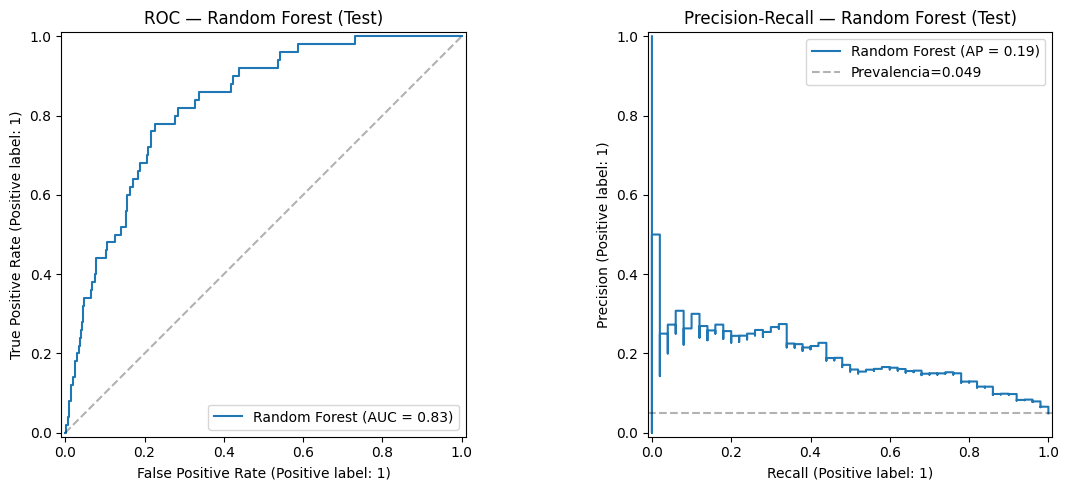

In [9]:
if y_prob_test is not None:
    fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 5))

    RocCurveDisplay.from_predictions(y_test, y_prob_test, name=final_name, ax=ax_roc)
    ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax_roc.set_title(f'ROC — {final_name} (Test)')

    PrecisionRecallDisplay.from_predictions(y_test, y_prob_test, name=final_name, ax=ax_pr)
    prevalence_test = y_test.mean() if hasattr(y_test, 'mean') else np.mean(y_test)
    ax_pr.axhline(prevalence_test, color='k', linestyle='--', alpha=0.3,
                  label=f'Prevalencia={prevalence_test:.3f}')
    ax_pr.legend(loc='upper right')
    ax_pr.set_title(f'Precision-Recall — {final_name} (Test)')

    plt.tight_layout()
    plt.show()
else:
    print('El modelo final no expone predict_proba; se omite ROC/PR.')

## Matriz de confusión en test

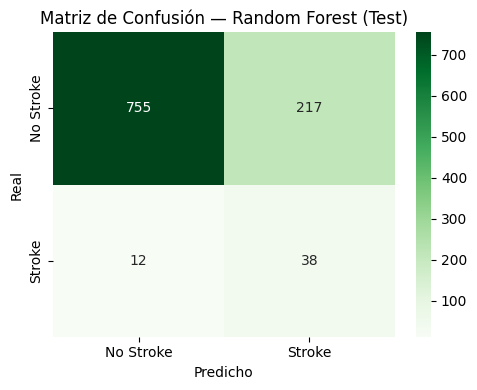

In [10]:
cm_test = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Stroke', 'Stroke'], yticklabels=['No Stroke', 'Stroke'])
plt.title(f'Matriz de Confusión — {final_name} (Test)')
plt.xlabel('Predicho'); plt.ylabel('Real')
plt.tight_layout()
plt.show()

## Conclusiones
